In [2]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [3]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP
0,1030456,0,1030456,3519,263210,9,2,"[[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...","[[2128, 2128, 2129, 2132, 2132, 2130, 2133, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
1,3274338,0,3274338,3803,263210,9,1,"[[2110, 2200, 2063, 2231, 2197, 2243, 2190, 20...","[[2127, 2132, 2125, 2133, 2132, 2134, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
2,3679960,0,3679960,3805,263210,9,8,"[[2109, 2063, 2115, 2171, 2186, 2107, 2261, 22...","[[2127, 2125, 2128, 2130, 2131, 2127, 2134, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3,6391145,0,6391145,1011,263211,9,1,"[[2085, 2210, 2268, 2181, 2261, 2070, 2185, 21...","[[2126, 2132, 2135, 2131, 2135, 2125, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
4,10916501,0,10916501,1209,263211,9,1,"[[2126, 2191, 2261, 2007, 2195, 2182, 2129, 22...","[[2128, 2131, 2135, 2122, 2131, 2131, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 123,..."
...,...,...,...,...,...,...,...,...,...,...
3157,316424396,9,9316424396,7915,266398,9,8,"[[2152, 2187, 2166, 2148, 2147, 2127, 2174, 21...","[[2129, 2131, 2130, 2129, 2129, 2128, 2130, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3158,321000985,9,9321000985,8402,266398,9,9,"[[2113, 2050, 2263, 2073, 2132, 2078, 2293, 20...","[[2127, 2124, 2135, 2125, 2128, 2126, 2136, 21...","[[255, 255, 255, 158, 255, 255, 255, 255, 255,..."
3159,326043880,9,9326043880,1403,266399,9,9,"[[2385, 2234, 2198, 2229, 2154, 2125, 2167, 21...","[[2141, 2133, 2132, 2133, 2129, 2128, 2130, 21...","[[117, 255, 255, 255, 255, 255, 255, 255, 255,..."
3160,329345615,9,9329345615,2419,266399,9,6,"[[2147, 2090, 2225, 2220, 2201, 2126, 2132, 22...","[[2129, 2126, 2133, 2133, 2132, 2128, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."


In [4]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [5]:
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-3, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo (UNICO, definitivo) ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1


def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])


def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [6]:
# ======================= CALCOLO INTERSEZIONI =======================

inters_hg = []
inters_lg = []

dfR = pd.DataFrame(results)

for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(
                rette_hg[i]["p0"], d1,
                rette_hg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)


In [7]:
from sklearn.cluster import DBSCAN

epsilon = 200
min_samples = 1

# ======================= HG =======================
dist_hg = []
delta_hg = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "HG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        # ---------- pesi angolari (VETTORIALI) ----------
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2   # sin^2(theta)

        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- diagnostica ----------
        delta_hg.append(np.linalg.norm(P_weight - P_simple))

        # ---------- distanze ----------
        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_hg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })
                

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        pairs = np.array(dfP["pair"].tolist())
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        delta_lg.append(np.linalg.norm(P_weight - P_simple))

        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_lg.append({
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })

df_dist_lg = pd.DataFrame(dist_lg)


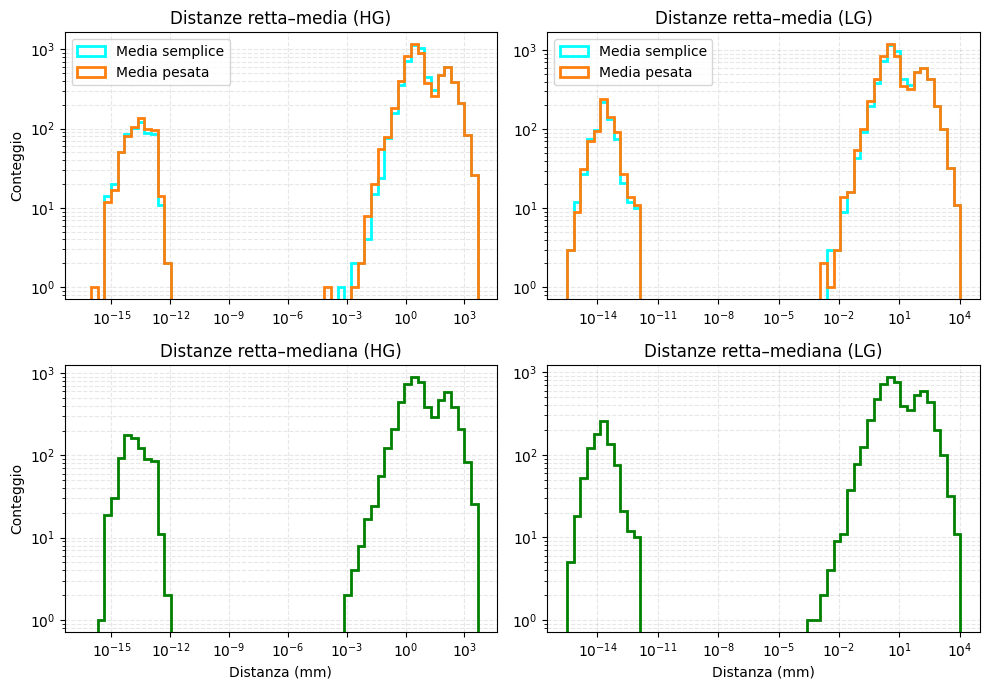

In [33]:
n_bins = 60

# ===================== HG =====================
d_s_hg = df_dist_hg["d_simple"].values
d_w_hg = df_dist_hg["d_weight"].values
d_m_hg = df_dist_hg["d_median"].values

d_s_hg = d_s_hg[np.isfinite(d_s_hg) & (d_s_hg > 0)]
d_w_hg = d_w_hg[np.isfinite(d_w_hg) & (d_w_hg > 0)]
d_m_hg = d_m_hg[np.isfinite(d_m_hg) & (d_m_hg > 0)]

# ===================== LG =====================
d_s_lg = df_dist_lg["d_simple"].values
d_w_lg = df_dist_lg["d_weight"].values
d_m_lg = df_dist_lg["d_median"].values

d_s_lg = d_s_lg[np.isfinite(d_s_lg) & (d_s_lg > 0)]
d_w_lg = d_w_lg[np.isfinite(d_w_lg) & (d_w_lg > 0)]
d_m_lg = d_m_lg[np.isfinite(d_m_lg) & (d_m_lg > 0)]

# ===================== BINNING LOG MIN–MAX =====================
# HG
bins_s_hg = np.logspace(np.log10(d_s_hg.min()), np.log10(d_s_hg.max()), n_bins)
bins_w_hg = np.logspace(np.log10(d_w_hg.min()), np.log10(d_w_hg.max()), n_bins)
bins_m_hg = np.logspace(np.log10(d_m_hg.min()), np.log10(d_m_hg.max()), n_bins)

all_mean_hg = np.concatenate([d_s_hg, d_w_hg])
bins_hg = np.logspace(np.log10(all_mean_hg.min()),
                      np.log10(all_mean_hg.max()), n_bins)

# LG
bins_s_lg = np.logspace(np.log10(d_s_lg.min()), np.log10(d_s_lg.max()), n_bins)
bins_w_lg = np.logspace(np.log10(d_w_lg.min()), np.log10(d_w_lg.max()), n_bins)
bins_m_lg = np.logspace(np.log10(d_m_lg.min()), np.log10(d_m_lg.max()), n_bins)

all_mean_lg = np.concatenate([d_s_lg, d_w_lg])
bins_lg = np.logspace(np.log10(all_mean_lg.min()),
                      np.log10(all_mean_lg.max()), n_bins)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_s_hg, bins=bins_hg, histtype="step", linewidth=2,
               color="cyan", label="Media semplice")
axes[0,0].hist(d_w_hg, bins=bins_hg, histtype="step", linewidth=2,
               color="tab:orange", label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_m_hg, bins=bins_m_hg, histtype="step",
               linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# -------------------- LG --------------------
axes[0,1].hist(d_s_lg, bins=bins_lg, histtype="step", linewidth=2,
               color="cyan", label="Media semplice")
axes[0,1].hist(d_w_lg, bins=bins_lg, histtype="step", linewidth=2,
               color="tab:orange", label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_m_lg, bins=bins_m_lg, histtype="step",
               linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()


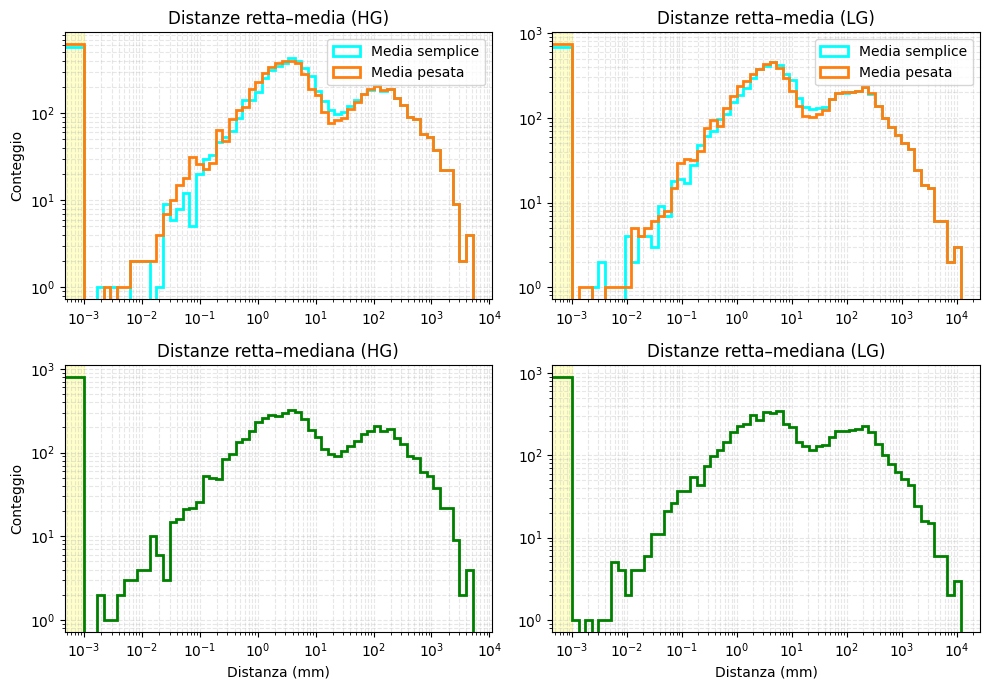

In [32]:
zero_threshold = 1e-3
n_bins = 60

# ===================== HG =====================
# estrai e filtra valori validi (>0 e finiti)
d_s_hg = df_dist_hg["d_simple"].values
d_w_hg = df_dist_hg["d_weight"].values
d_m_hg = df_dist_hg["d_median"].values

d_s_hg = d_s_hg[np.isfinite(d_s_hg) & (d_s_hg > 0)]
d_w_hg = d_w_hg[np.isfinite(d_w_hg) & (d_w_hg > 0)]
d_m_hg = d_m_hg[np.isfinite(d_m_hg) & (d_m_hg > 0)]

# ===================== LG =====================
d_s_lg = df_dist_lg["d_simple"].values
d_w_lg = df_dist_lg["d_weight"].values
d_m_lg = df_dist_lg["d_median"].values

d_s_lg = d_s_lg[np.isfinite(d_s_lg) & (d_s_lg > 0)]
d_w_lg = d_w_lg[np.isfinite(d_w_lg) & (d_w_lg > 0)]
d_m_lg = d_m_lg[np.isfinite(d_m_lg) & (d_m_lg > 0)]

# ===================== BINNING INTELLIGENTE =====================
# HG
all_mean_hg = np.concatenate([d_s_hg, d_w_hg])

bins_hg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(all_mean_hg.max() * 1.1),
        n_bins
    )
]))

bins_median_hg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(d_m_hg.max() * 1.1),
        n_bins
    )
]))

# LG
all_mean_lg = np.concatenate([d_s_lg, d_w_lg])

bins_lg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(all_mean_lg.max() * 1.1),
        n_bins
    )
]))

bins_median_lg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(d_m_lg.max() * 1.1),
        n_bins
    )
]))

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_s_hg, bins=bins_hg, histtype="step", linewidth=2,
               color="cyan", label="Media semplice")
axes[0,0].hist(d_w_hg, bins=bins_hg, histtype="step", linewidth=2,
               color="tab:orange", label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_m_hg, bins=bins_median_hg, histtype="step",
               linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# -------------------- LG --------------------
axes[0,1].hist(d_s_lg, bins=bins_lg, histtype="step", linewidth=2,
               color="cyan", label="Media semplice")
axes[0,1].hist(d_w_lg, bins=bins_lg, histtype="step", linewidth=2,
               color="tab:orange", label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_m_lg, bins=bins_median_lg, histtype="step",
               linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

# evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, color="yellow", alpha=0.2)

plt.tight_layout()
plt.show()


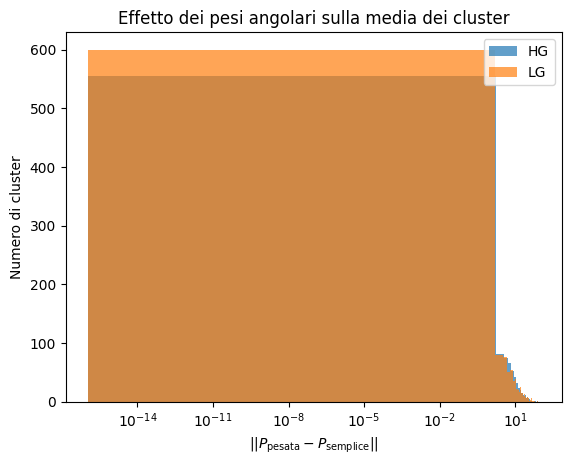

In [8]:
plt.figure()
plt.hist(delta_hg, bins=50, alpha=0.7, label="HG")
plt.hist(delta_lg, bins=50, alpha=0.7, label="LG")
plt.xscale("log")
plt.xlabel(r"$||P_{\mathrm{pesata}} - P_{\mathrm{semplice}}||$")
plt.ylabel("Numero di cluster")
plt.legend()
plt.title("Effetto dei pesi angolari sulla media dei cluster")
plt.show()


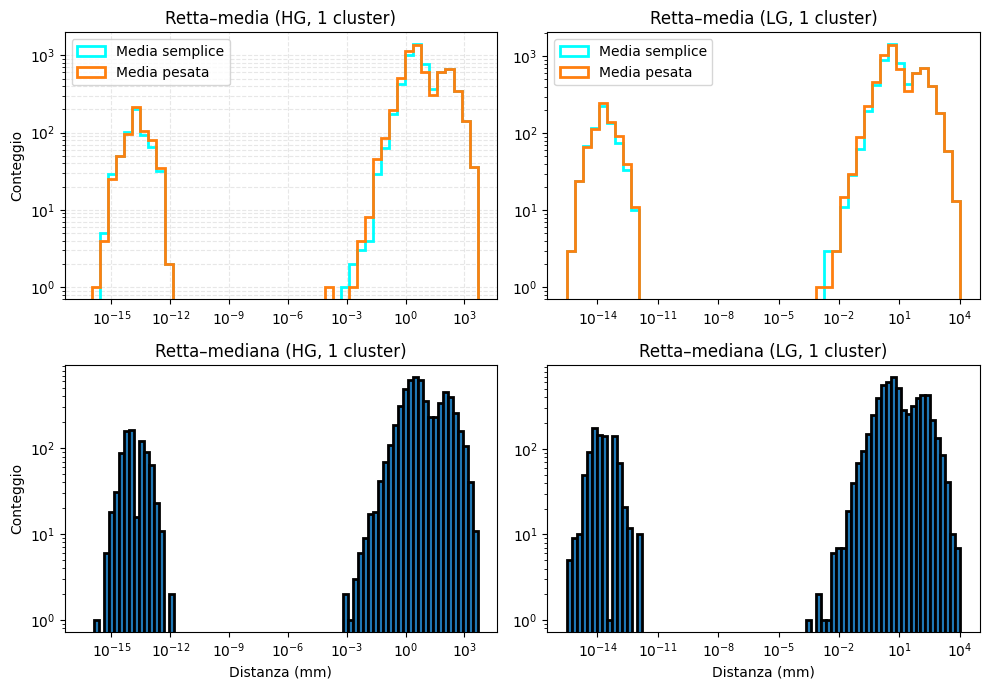

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# ===================== HG =====================
# estrai e filtra valori validi (>0 e finiti)
d_s_hg = df_dist_hg["d_simple"].values
d_w_hg = df_dist_hg["d_weight"].values
d_m_hg = df_dist_hg["d_median"].values

d_s_hg = d_s_hg[np.isfinite(d_s_hg) & (d_s_hg > 0)]
d_w_hg = d_w_hg[np.isfinite(d_w_hg) & (d_w_hg > 0)]
d_m_hg = d_m_hg[np.isfinite(d_m_hg) & (d_m_hg > 0)]

# bins logaritmici separati
bins_s_hg = np.logspace(np.log10(d_s_hg.min()), np.log10(d_s_hg.max()), 80)
bins_w_hg = np.logspace(np.log10(d_w_hg.min()), np.log10(d_w_hg.max()), 80)
bins_m_hg = np.logspace(np.log10(d_m_hg.min()), np.log10(d_m_hg.max()), 80)

# histogram HG
# calcolo bin comune logaritmico
all_data_hg = np.concatenate([d_s_hg, d_w_hg])
bins_hg = np.logspace(np.log10(all_data_hg.min()), np.log10(all_data_hg.max()), 50)

# Retta–media HG
axes[0,0].hist(d_s_hg, bins=bins_hg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,0].hist(d_w_hg, bins=bins_hg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_title("Retta–media (HG, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_m_hg, bins=bins_m_hg, linewidth=2,edgecolor="black")
axes[1,0].set_title("Retta–mediana (HG, 1 cluster)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# ===================== LG =====================
d_s_lg = df_dist_lg["d_simple"].values
d_w_lg = df_dist_lg["d_weight"].values
d_m_lg = df_dist_lg["d_median"].values

d_s_lg = d_s_lg[np.isfinite(d_s_lg) & (d_s_lg > 0)]
d_w_lg = d_w_lg[np.isfinite(d_w_lg) & (d_w_lg > 0)]
d_m_lg = d_m_lg[np.isfinite(d_m_lg) & (d_m_lg > 0)]

# bins logaritmici separati
bins_s_lg = np.logspace(np.log10(d_s_lg.min()), np.log10(d_s_lg.max()), 80)
bins_w_lg = np.logspace(np.log10(d_w_lg.min()), np.log10(d_w_lg.max()), 80)
bins_m_lg = np.logspace(np.log10(d_m_lg.min()), np.log10(d_m_lg.max()), 80)
all_data_lg = np.concatenate([d_s_lg, d_w_lg])

bins_lg = np.logspace(np.log10(all_data_lg.min()), np.log10(all_data_lg.max()), 50)

# histogram LG
axes[0,1].hist(d_s_lg, bins=bins_lg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,1].hist(d_w_lg, bins=bins_lg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,1].set_title("Retta–media (LG, 1 cluster)")
axes[0,1].legend()

axes[1,1].hist(d_m_lg, bins=bins_m_lg, linewidth=2,edgecolor="black")
axes[1,1].set_title("Retta–mediana (LG, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


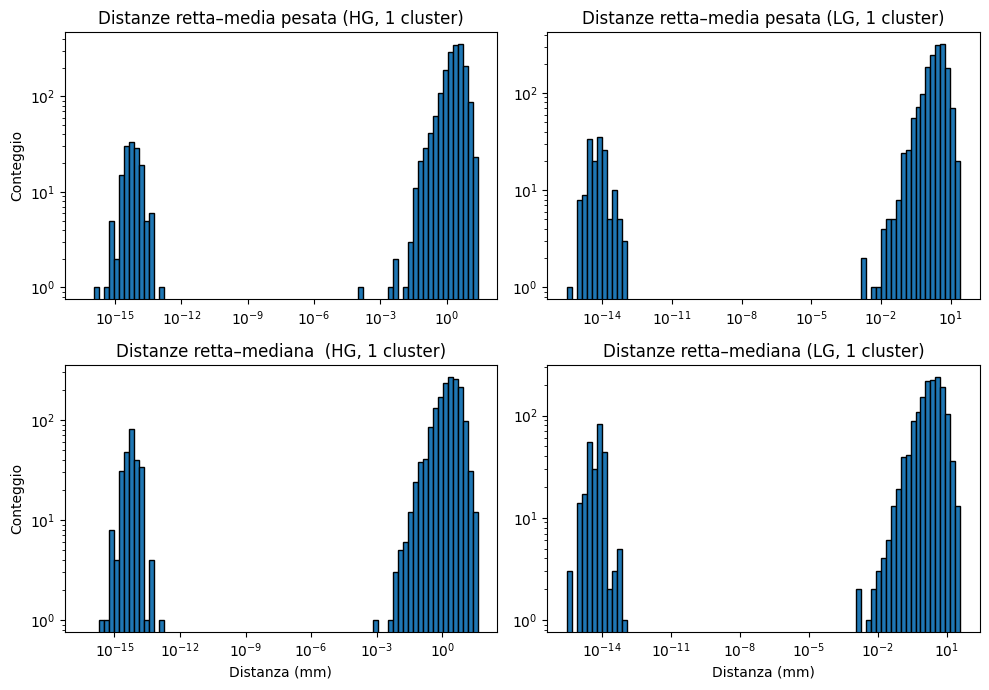

In [10]:
# -------------------- SELEZIONE EVENTI CON 1 CLUSTER --------------------
# HG
eventi_cluster_hg = df_dist_hg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_hg = eventi_cluster_hg[eventi_cluster_hg == 1].index
df_sel_hg = df_dist_hg.set_index(["event","mcrun"]).loc[eventi_validi_hg].reset_index()

# LG
eventi_cluster_lg = df_dist_lg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_lg = eventi_cluster_lg[eventi_cluster_lg == 1].index
df_sel_lg = df_dist_lg.set_index(["event","mcrun"]).loc[eventi_validi_lg].reset_index()

# -------------------- ESTRAZIONE DISTANZE --------------------
d_mean_hg   = df_sel_hg["d_weight"].values
d_median_hg = df_sel_hg["d_median"].values
d_mean_lg   = df_sel_lg["d_weight"].values
d_median_lg = df_sel_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
bins_mean_hg   = np.logspace(np.log10(d_mean_hg.min()),   np.log10(d_mean_hg.max()),   80)
bins_median_hg = np.logspace(np.log10(d_median_hg.min()), np.log10(d_median_hg.max()), 80)
bins_mean_lg   = np.logspace(np.log10(d_mean_lg.min()),   np.log10(d_mean_lg.max()),   80)
bins_median_lg = np.logspace(np.log10(d_median_lg.min()), np.log10(d_median_lg.max()), 80)

# -------------------- PLOT --------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media pesata (HG, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana  (HG, 1 cluster)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media pesata (LG, 1 cluster)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


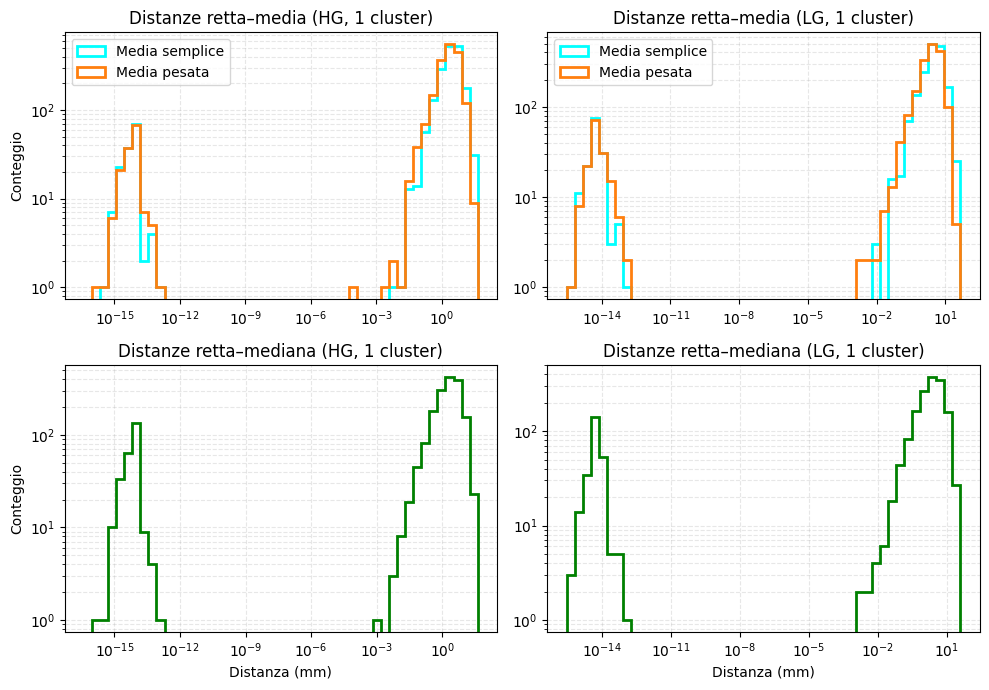

In [11]:
# -------------------- SELEZIONE EVENTI CON 1 CLUSTER --------------------
# HG
eventi_cluster_hg = df_dist_hg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_hg = eventi_cluster_hg[eventi_cluster_hg == 1].index
df_sel_hg = df_dist_hg.set_index(["event","mcrun"]).loc[eventi_validi_hg].reset_index()

# LG
eventi_cluster_lg = df_dist_lg.groupby(["event","mcrun"])["cluster"].nunique()
eventi_validi_lg = eventi_cluster_lg[eventi_cluster_lg == 1].index
df_sel_lg = df_dist_lg.set_index(["event","mcrun"]).loc[eventi_validi_lg].reset_index()

# -------------------- ESTRAZIONE DISTANZE --------------------
d_simple_hg   = df_sel_hg["d_simple"].values
d_weight_hg   = df_sel_hg["d_weight"].values
d_median_hg   = df_sel_hg["d_median"].values

d_simple_lg   = df_sel_lg["d_simple"].values
d_weight_lg   = df_sel_lg["d_weight"].values
d_median_lg   = df_sel_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_simple_hg = d_simple_hg[np.isfinite(d_simple_hg) & (d_simple_hg > 0)]
d_weight_hg = d_weight_hg[np.isfinite(d_weight_hg) & (d_weight_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]

d_simple_lg = d_simple_lg[np.isfinite(d_simple_lg) & (d_simple_lg > 0)]
d_weight_lg = d_weight_lg[np.isfinite(d_weight_lg) & (d_weight_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BIN LOGARITMICO --------------------
bins_hg = np.logspace(np.log10(min(d_simple_hg.min(), d_weight_hg.min())),
                      np.log10(max(d_simple_hg.max(), d_weight_hg.max())), 50)

bins_lg = np.logspace(np.log10(min(d_simple_lg.min(), d_weight_lg.min())),
                      np.log10(max(d_simple_lg.max(), d_weight_lg.max())), 50)

bins_median_hg = np.logspace(np.log10(d_median_hg.min()), np.log10(d_median_hg.max()), 50)
bins_median_lg = np.logspace(np.log10(d_median_lg.min()), np.log10(d_median_lg.max()), 50)

# -------------------- PLOT --------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_simple_hg, bins=bins_hg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,0].hist(d_weight_hg, bins=bins_hg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, histtype="step", linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG, 1 cluster)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# -------------------- LG --------------------
axes[0,1].hist(d_simple_lg, bins=bins_lg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,1].hist(d_weight_lg, bins=bins_lg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG, 1 cluster)")
axes[0,1].legend()
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, histtype="step", linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()


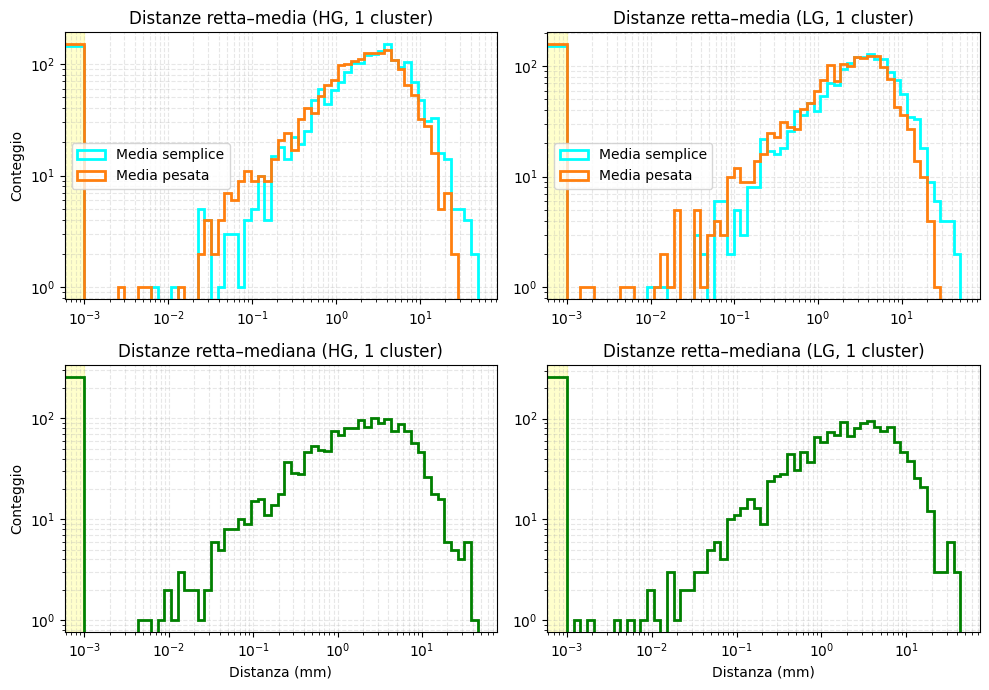

In [30]:
zero_threshold=1e-3
n_bins=60
# ===================== BIN =====================
all_mean_hg = np.concatenate([d_simple_hg, d_weight_hg])

bins_hg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(all_mean_hg.max() * 1.1),
        n_bins
    )
]))

bins_median_hg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(d_median_hg.max() * 1.1),
        n_bins
    )
]))
all_mean_lg = np.concatenate([d_simple_lg, d_weight_lg])

bins_lg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(all_mean_lg.max() * 1.1),
        n_bins
    )
]))

bins_median_lg = np.unique(np.concatenate([
    [0, zero_threshold],
    np.logspace(
        np.log10(zero_threshold),
        np.log10(d_median_lg.max() * 1.1),
        n_bins
    )
]))
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_simple_hg, bins=bins_hg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,0].hist(d_weight_hg, bins=bins_hg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, histtype="step", linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG, 1 cluster)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# -------------------- LG --------------------
axes[0,1].hist(d_simple_lg, bins=bins_lg, histtype="step", linewidth=2, color="cyan", label="Media semplice")
axes[0,1].hist(d_weight_lg, bins=bins_lg, histtype="step", linewidth=2, color="tab:orange", label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG, 1 cluster)")
axes[0,1].legend()
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, histtype="step", linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, color="yellow", alpha=0.2)

plt.tight_layout()
plt.show()


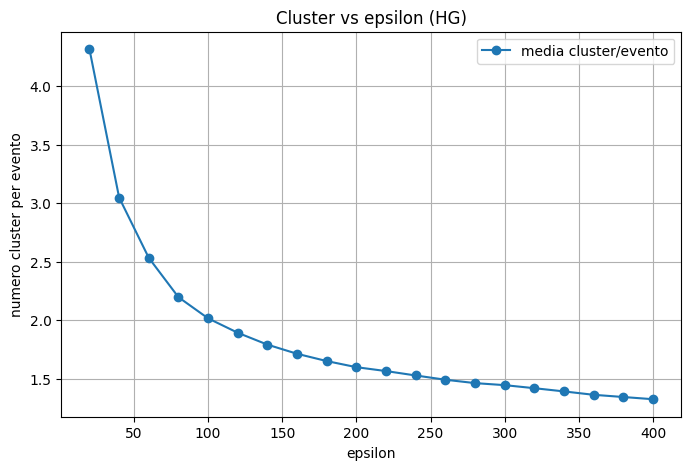

In [12]:
#STUDIO DELL'EPSILON

eps_values = np.linspace(20, 400, 20)  # prova eps da 1 a 20
n_cluster_per_event = []

for eps in eps_values:
    cluster_counts = []
    for (event, mcrun), df_evt in df_int_hg.groupby(["event","mcrun"]):
        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue
        labels = DBSCAN(eps=eps, min_samples=1).fit_predict(P)
        cl_labels = set(labels) - {-1}
        cluster_counts.append(len(cl_labels))
    n_cluster_per_event.append(cluster_counts)

# calcolo statistiche
mean_clusters = [np.mean(x) if len(x)>0 else 0 for x in n_cluster_per_event]
#median_clusters = [np.median(x) if len(x)>0 else 0 for x in n_cluster_per_event]

# plot
plt.figure(figsize=(8,5))
plt.plot(eps_values, mean_clusters, marker='o', label="media cluster/evento")
#plt.plot(eps_values, median_clusters, marker='x', label="mediana cluster/evento")
plt.xlabel("epsilon")
plt.ylabel("numero cluster per evento")
plt.title("Cluster vs epsilon (HG)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]


fake_events = []

for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
    # etichetta evento fittizio
    df_fake["FAKE_EVENT"] = i
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns


Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [14]:
#########ora stessa analisi di sopra
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results_f = []

for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results_f.append({
            "r_event": np.array([row["MCRUN"],row["EVENT"]]),
            "fevent": fevent,   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


In [15]:
# ======================= CALCOLO INTERSEZIONI =======================

inters_hg_f = []
inters_lg_f = []

dfR_f = pd.DataFrame(results_f)  # il dataframe con fevent, HG, LG

for fevent, df_evt in dfR_f.groupby("fevent"):   # <<< raggruppo per fevent

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            # --- ignora rette quasi parallele ---
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-3:
                continue

            P = intersection(
                rette_hg[i]["p0"], d1,
                rette_hg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_hg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            # --- ignora rette quasi parallele ---
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < 1e-3:
                continue

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j)
            })

# dataframe finali
df_int_hg_f = pd.DataFrame(inters_hg_f)
df_int_lg_f = pd.DataFrame(inters_lg_f)


In [27]:

epsilon = 350
min_samples = 1

# ======================= HG =======================
dist_hg_f = []

for fevent, df_evt in df_int_hg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento falso
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "HG"]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            i, j = row["pair"]          
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            dist_hg_f.append({
                "fevent": fevent,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_mean_weighted": dm_w,
                "d_median": dmed
            })

df_dist_hg_f = pd.DataFrame(dist_hg_f)

# ======================= LG =======================
dist_lg_f = []

for fevent, df_evt in df_int_lg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "LG"]

    p0  = np.array([r["p0"] for r in dfR_evt])
    d   = np.array([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # pesi angolari
        w = []
        for _, row in dfP.iterrows():
            i, j = row["pair"]
            d1 = dfR_evt.iloc[i]["d"]
            d2 = dfR_evt.iloc[j]["d"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            dist_lg_f.append({
                "fevent": fevent,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_mean_weighted": dm_w,
                "d_median": dmed
            })

df_dist_lg_f = pd.DataFrame(dist_lg_f)


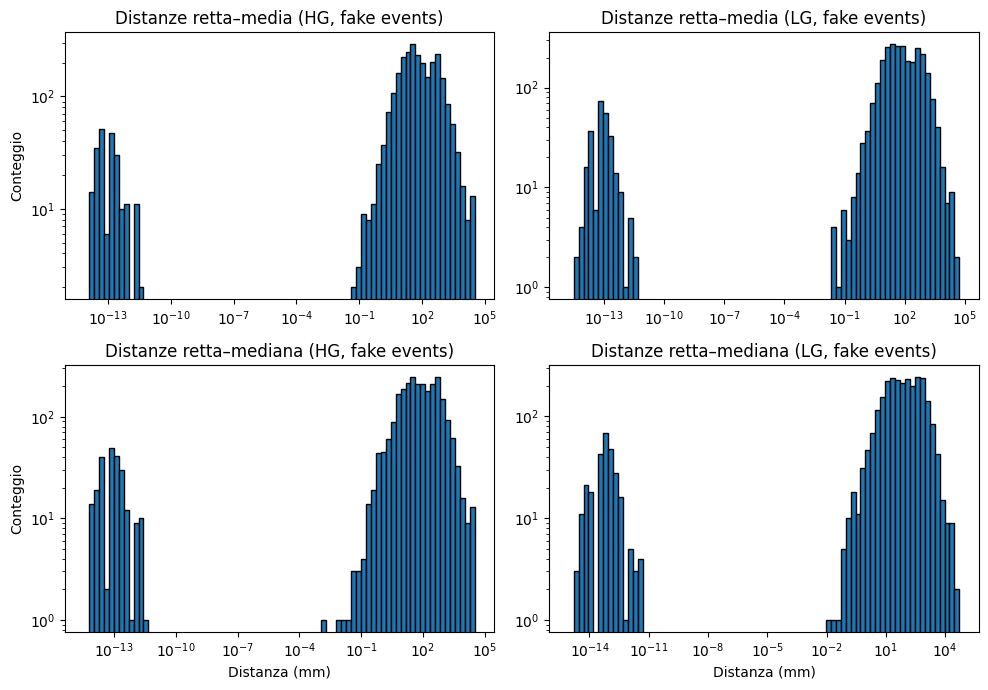

In [37]:
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_f   = df_dist_hg_f["d_mean_weighted"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f   = df_dist_lg_f["d_mean_weighted"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg_f   = d_mean_hg_f[np.isfinite(d_mean_hg_f) & (d_mean_hg_f > 0)]
d_median_hg_f = d_median_hg_f[np.isfinite(d_median_hg_f) & (d_median_hg_f > 0)]
d_mean_lg_f   = d_mean_lg_f[np.isfinite(d_mean_lg_f) & (d_mean_lg_f > 0)]
d_median_lg_f = d_median_lg_f[np.isfinite(d_median_lg_f) & (d_median_lg_f > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
bins_mean_hg   = np.logspace(np.log10(d_mean_hg_f.min()),   np.log10(d_mean_hg_f.max()),   80)
bins_median_hg = np.logspace(np.log10(d_median_hg_f.min()), np.log10(d_median_hg_f.max()), 80)
bins_mean_lg   = np.logspace(np.log10(d_mean_lg_f.min()),   np.log10(d_mean_lg_f.max()),   80)
bins_median_lg = np.logspace(np.log10(d_median_lg_f.min()), np.log10(d_median_lg_f.max()), 80)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, fake events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, fake events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, fake events)")

axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, fake events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


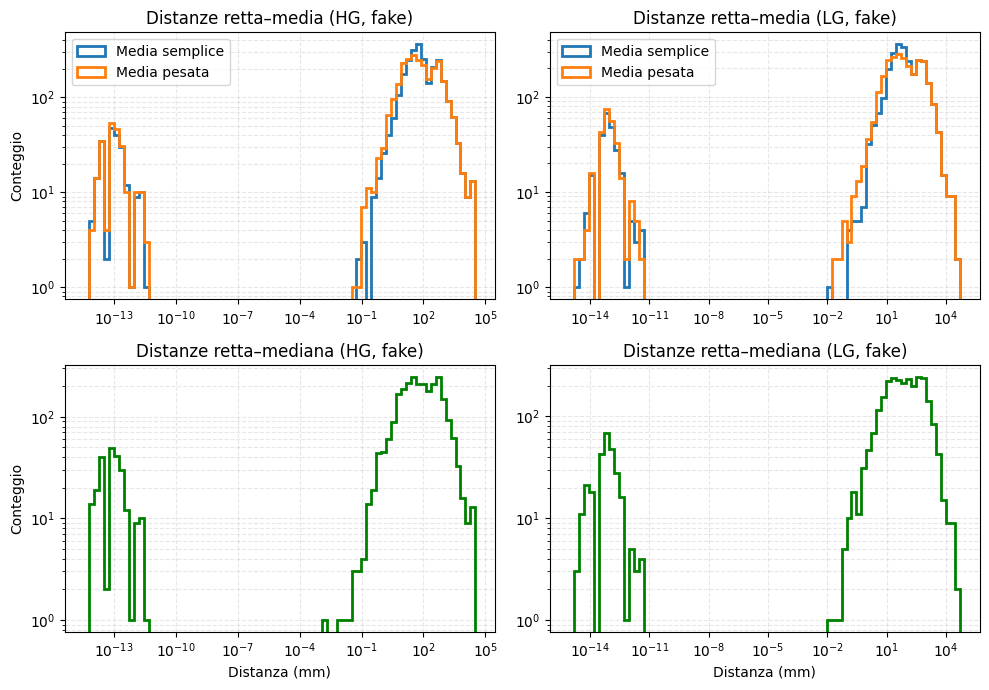

In [38]:
# ===================== ESTRAZIONE DATI (FAKE) =====================
# HG
d_s_hg_f = df_dist_hg_f["d_mean_simple"].values
d_w_hg_f = df_dist_hg_f["d_mean_weighted"].values
d_m_hg_f = df_dist_hg_f["d_median"].values

# LG
d_s_lg_f = df_dist_lg_f["d_mean_simple"].values
d_w_lg_f = df_dist_lg_f["d_mean_weighted"].values
d_m_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
def clean(x):
    return x[np.isfinite(x) & (x > 0)]

d_s_hg_f = clean(d_s_hg_f)
d_w_hg_f = clean(d_w_hg_f)
d_m_hg_f = clean(d_m_hg_f)

d_s_lg_f = clean(d_s_lg_f)
d_w_lg_f = clean(d_w_lg_f)
d_m_lg_f = clean(d_m_lg_f)

# ===================== BINNING LOG MIN–MAX =====================
# HG
all_mean_hg_f = np.concatenate([d_s_hg_f, d_w_hg_f])
bins_hg_f = np.logspace(np.log10(all_mean_hg_f.min()),
                        np.log10(all_mean_hg_f.max()), 80)
bins_median_hg_f = np.logspace(np.log10(d_m_hg_f.min()),
                               np.log10(d_m_hg_f.max()), 80)

# LG
all_mean_lg_f = np.concatenate([d_s_lg_f, d_w_lg_f])
bins_lg_f = np.logspace(np.log10(all_mean_lg_f.min()),
                        np.log10(all_mean_lg_f.max()), 80)
bins_median_lg_f = np.logspace(np.log10(d_m_lg_f.min()),
                               np.log10(d_m_lg_f.max()), 80)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_s_hg_f, bins=bins_hg_f, histtype="step",
               linewidth=2, label="Media semplice")
axes[0,0].hist(d_w_hg_f, bins=bins_hg_f, histtype="step",
               linewidth=2, label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG, fake)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

axes[1,0].hist(d_m_hg_f, bins=bins_median_hg_f, histtype="step",
               linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG, fake)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")

# -------------------- LG --------------------
axes[0,1].hist(d_s_lg_f, bins=bins_lg_f, histtype="step",
               linewidth=2, label="Media semplice")
axes[0,1].hist(d_w_lg_f, bins=bins_lg_f, histtype="step",
               linewidth=2, label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG, fake)")
axes[0,1].legend()

axes[1,1].hist(d_m_lg_f, bins=bins_median_lg_f, histtype="step",
               linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG, fake)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


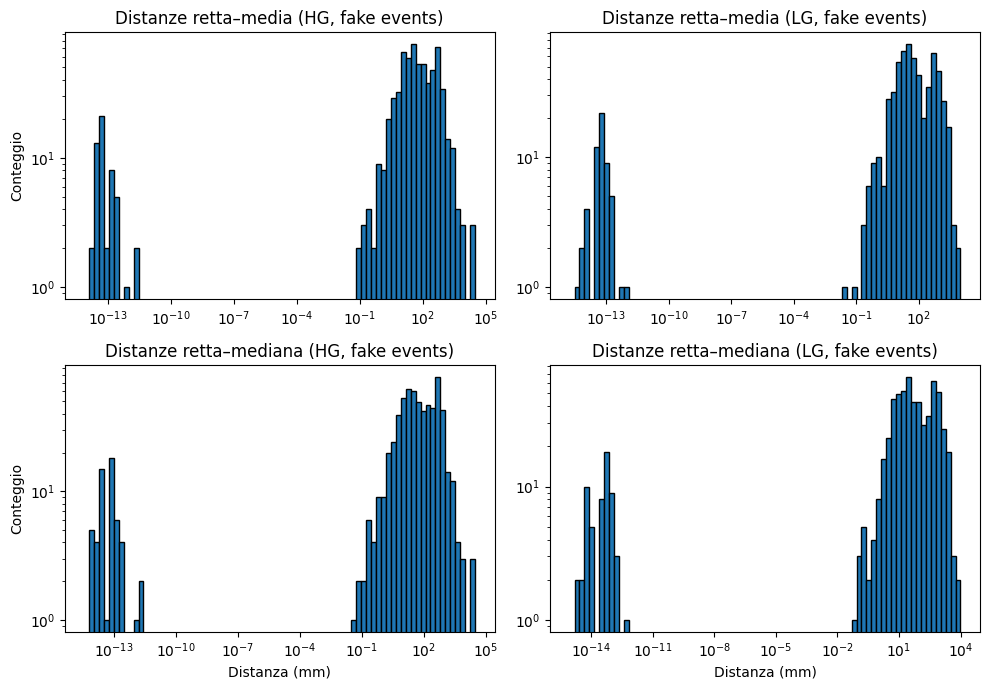

In [39]:
# -------------------- SELEZIONE EVENTI CON 1 CLUSTER --------------------
# HG
eventi_cluster_hg = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg = eventi_cluster_hg[eventi_cluster_hg == 2].index
df_sel_hg = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg].reset_index()

# LG
eventi_cluster_lg = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg = eventi_cluster_lg[eventi_cluster_lg == 2].index
df_sel_lg = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg].reset_index()

d_mean_hg_f   = df_sel_hg["d_mean_weighted"].values
d_median_hg_f = df_sel_hg["d_median"].values
d_mean_lg_f   = df_sel_lg["d_mean_weighted"].values
d_median_lg_f = df_sel_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg_f   = d_mean_hg_f[np.isfinite(d_mean_hg_f) & (d_mean_hg_f > 0)]
d_median_hg_f = d_median_hg_f[np.isfinite(d_median_hg_f) & (d_median_hg_f > 0)]
d_mean_lg_f   = d_mean_lg_f[np.isfinite(d_mean_lg_f) & (d_mean_lg_f > 0)]
d_median_lg_f = d_median_lg_f[np.isfinite(d_median_lg_f) & (d_median_lg_f > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
bins_mean_hg   = np.logspace(np.log10(d_mean_hg_f.min()),   np.log10(d_mean_hg_f.max()),   80)
bins_median_hg = np.logspace(np.log10(d_median_hg_f.min()), np.log10(d_median_hg_f.max()), 80)
bins_mean_lg   = np.logspace(np.log10(d_mean_lg_f.min()),   np.log10(d_mean_lg_f.max()),   80)
bins_median_lg = np.logspace(np.log10(d_median_lg_f.min()), np.log10(d_median_lg_f.max()), 80)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, fake events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, fake events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, fake events)")

axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, fake events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


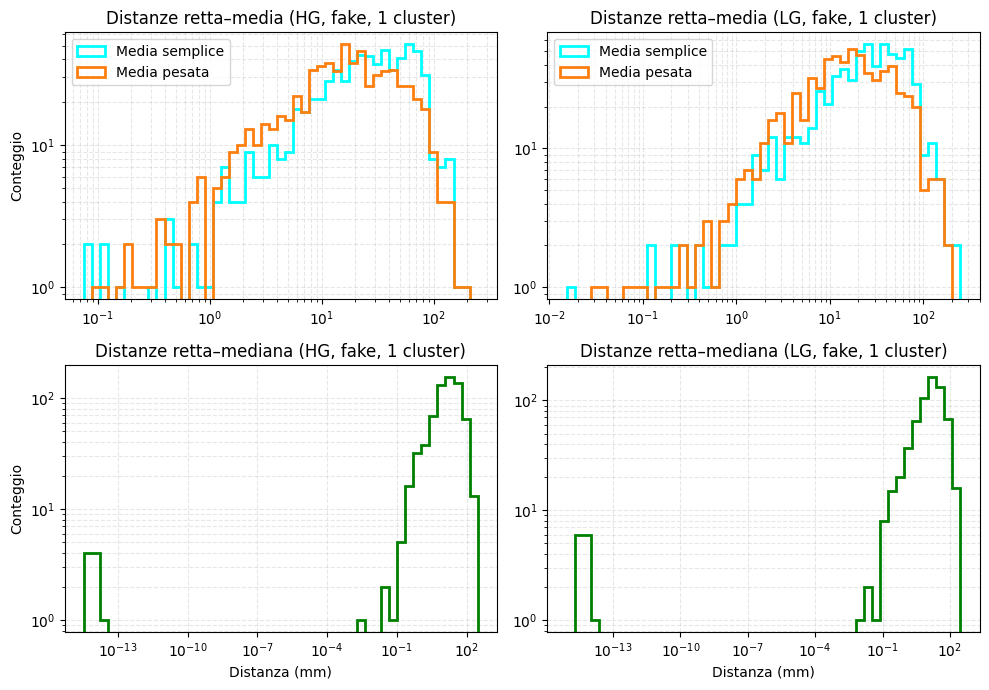

In [43]:
eventi_cluster_hg_f = (
    df_dist_hg_f
    .groupby("fevent")["cluster"]
    .nunique()
)

eventi_validi_hg_f = eventi_cluster_hg_f[eventi_cluster_hg_f == 1].index

df_sel_hg_f = (
    df_dist_hg_f
    .set_index("fevent")
    .loc[eventi_validi_hg_f]
    .reset_index()
)
eventi_cluster_lg_f = (
    df_dist_lg_f
    .groupby("fevent")["cluster"]
    .nunique()
)

eventi_validi_lg_f = eventi_cluster_lg_f[eventi_cluster_lg_f == 1].index

df_sel_lg_f = (
    df_dist_lg_f
    .set_index("fevent")
    .loc[eventi_validi_lg_f]
    .reset_index()
)
# HG
d_s_hg_f = df_sel_hg_f["d_mean_simple"].values
d_w_hg_f = df_sel_hg_f["d_mean_weighted"].values
d_m_hg_f = df_sel_hg_f["d_median"].values

# LG
d_s_lg_f = df_sel_lg_f["d_mean_simple"].values
d_w_lg_f = df_sel_lg_f["d_mean_weighted"].values
d_m_lg_f = df_sel_lg_f["d_median"].values

# filtro valori validi
def clean(x):
    return x[np.isfinite(x) & (x > 0)]

d_s_hg_f = clean(d_s_hg_f)
d_w_hg_f = clean(d_w_hg_f)
d_m_hg_f = clean(d_m_hg_f)

d_s_lg_f = clean(d_s_lg_f)
d_w_lg_f = clean(d_w_lg_f)
d_m_lg_f = clean(d_m_lg_f)
# ===================== BIN LOGARITMICI (min–max) =====================
# HG
all_mean_hg_f = np.concatenate([d_s_hg_f, d_w_hg_f])

bins_hg_f = np.logspace(
    np.log10(all_mean_hg_f.min()),
    np.log10(all_mean_hg_f.max()),
    50
)

bins_median_hg_f = np.logspace(
    np.log10(d_m_hg_f.min()),
    np.log10(d_m_hg_f.max()),
    50
)

# LG
all_mean_lg_f = np.concatenate([d_s_lg_f, d_w_lg_f])

bins_lg_f = np.logspace(
    np.log10(all_mean_lg_f.min()),
    np.log10(all_mean_lg_f.max()),
    50
)

bins_median_lg_f = np.logspace(
    np.log10(d_m_lg_f.min()),
    np.log10(d_m_lg_f.max()),
    50
)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_s_hg_f, bins=bins_hg_f, histtype="step",
               linewidth=2, color="cyan", label="Media semplice")
axes[0,0].hist(d_w_hg_f, bins=bins_hg_f, histtype="step",
               linewidth=2, color="tab:orange", label="Media pesata")
axes[0,0].set_title("Distanze retta–media (HG, fake, 1 cluster)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()
axes[0,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_m_hg_f, bins=bins_median_hg_f, histtype="step",
               linewidth=2, color="green")
axes[1,0].set_title("Distanze retta–mediana (HG, fake, 1 cluster)")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

# -------------------- LG --------------------
axes[0,1].hist(d_s_lg_f, bins=bins_lg_f, histtype="step",
               linewidth=2, color="cyan", label="Media semplice")
axes[0,1].hist(d_w_lg_f, bins=bins_lg_f, histtype="step",
               linewidth=2, color="tab:orange", label="Media pesata")
axes[0,1].set_title("Distanze retta–media (LG, fake, 1 cluster)")
axes[0,1].legend()
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_m_lg_f, bins=bins_median_lg_f, histtype="step",
               linewidth=2, color="green")
axes[1,1].set_title("Distanze retta–mediana (LG, fake, 1 cluster)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.3)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()



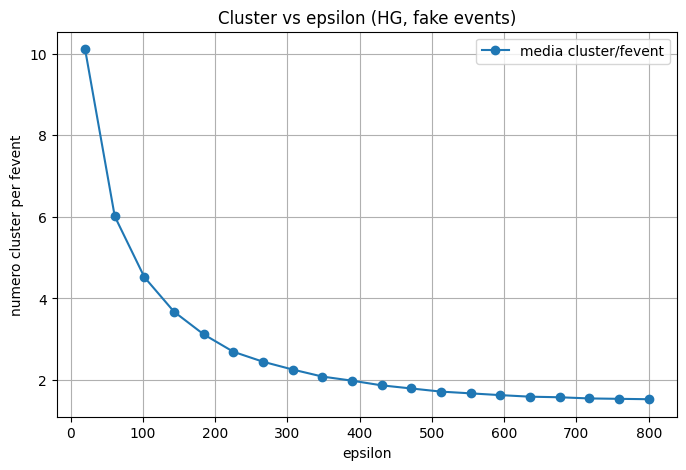

In [19]:


# ===================== STUDIO DELL'EPSILON =====================
eps_values = np.linspace(20, 800, 20)  # prova eps da 20 a 400
n_cluster_per_fevent = []

for eps in eps_values:
    cluster_counts = []
    for fevent, df_evt in df_int_hg_f.groupby("fevent"):
        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue
        labels = DBSCAN(eps=eps, min_samples=1).fit_predict(P)
        cl_labels = set(labels) - {-1}
        cluster_counts.append(len(cl_labels))
    n_cluster_per_fevent.append(cluster_counts)

# calcolo statistiche
mean_clusters = [np.mean(x) if len(x) > 0 else 0 for x in n_cluster_per_fevent]
# median_clusters = [np.median(x) if len(x) > 0 else 0 for x in n_cluster_per_fevent]

# plot
plt.figure(figsize=(8,5))
plt.plot(eps_values, mean_clusters, marker='o', label="media cluster/fevent")
# plt.plot(eps_values, median_clusters, marker='x', label="mediana cluster/fevent")
plt.xlabel("epsilon")
plt.ylabel("numero cluster per fevent")
plt.title("Cluster vs epsilon (HG, fake events)")
plt.legend()
plt.grid(True)
plt.show()


In [24]:

eps_values = np.linspace(1, 800, 20)
min_samples = 1

# ===================== DATI REALI =====================
n_cluster_per_event = []
for eps in eps_values:
    cluster_counts = []
    for (event, mcrun), df_evt in df_int_hg.groupby(["event","mcrun"]):
        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        cl_labels = set(labels) - {-1}
        cluster_counts.append(len(cl_labels))
    n_cluster_per_event.append(cluster_counts)

mean_clusters_real = [np.mean(x) if len(x) > 0 else 0 for x in n_cluster_per_event]
median_clusters_real = [np.median(x) if len(x) > 0 else 0 for x in n_cluster_per_event]

# ===================== DATI FAKE =====================
n_cluster_per_fevent = []
for eps in eps_values:
    cluster_counts = []
    for fevent, df_evt in df_int_hg_f.groupby("fevent"):   
        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        cl_labels = set(labels) - {-1}
        cluster_counts.append(len(cl_labels))
    n_cluster_per_fevent.append(cluster_counts)

mean_clusters_fake = [np.mean(x) if len(x) > 0 else 0 for x in n_cluster_per_fevent]
median_clusters_fake = [np.median(x) if len(x) > 0 else 0 for x in n_cluster_per_fevent]

# ===================== PLOT =====================


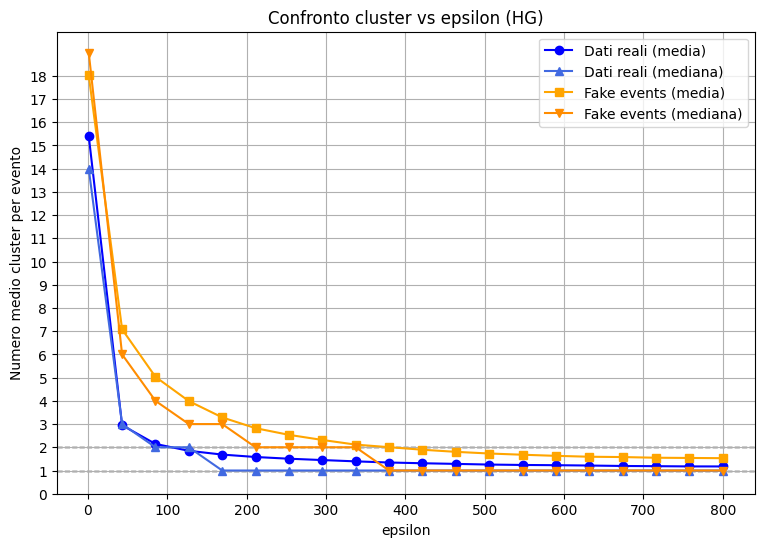

In [26]:
plt.figure(figsize=(9,6))
plt.plot(eps_values, mean_clusters_real, marker='o', color='blue', label="Dati reali (media)")
plt.plot(eps_values, median_clusters_real, marker='^', color='royalblue', label="Dati reali (mediana)")

plt.plot(eps_values, mean_clusters_fake, marker='s', color='orange', label="Fake events (media)")
plt.plot(eps_values, median_clusters_fake, marker='v', color='darkorange', label="Fake events (mediana)")
plt.xlabel("epsilon")
plt.ylabel("Numero medio cluster per evento")
plt.title("Confronto cluster vs epsilon (HG)")
plt.legend()
plt.axhline(y=1, color='black', linestyle='--', linewidth=1,zorder=1)
plt.axhline(y=2, color='black', linestyle='--', linewidth=1,zorder=1)
plt.grid(True)
plt.yticks(range(0, 19,1))
plt.show()


In [22]:
min_samples = 1
eps_values=[50,350,750]
print("=== REAL ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")
print("\n=== FAKE ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")


=== REAL ===
eps=50.0: 1 cluster = 29.1%, 2 cluster = 21.7%
eps=350.0: 1 cluster = 70.2%, 2 cluster = 23.9%
eps=750.0: 1 cluster = 83.9%, 2 cluster = 14.6%

=== FAKE ===
eps=50.0: 1 cluster = 1.4%, 2 cluster = 8.1%
eps=350.0: 1 cluster = 47.8%, 2 cluster = 26.3%
eps=750.0: 1 cluster = 68.4%, 2 cluster = 18.2%
